### CODE

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("talabat_enhanced_orders.csv")

df.head()
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [3]:
#1.check null values

df.isnull().sum()




Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [4]:
#2.check duplicate values

df.duplicated().sum()


0

In [5]:
#3.convert date and time columns

df['Order_Time'] = pd.to_datetime(df['Order_Time'])
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'])

df[['Order_Time', 'Delivery_Time']].head()




,Order_Time,Delivery_Time
0,2025-06-16 08:32:00,2025-06-16 09:11:00
1,2025-06-03 21:27:00,2025-06-03 22:00:00
2,2025-06-01 14:48:00,2025-06-01 15:26:00
3,2025-06-13 02:30:00,2025-06-13 03:22:00
4,2025-06-06 09:48:00,2025-06-06 10:32:00


In [6]:
#4.Creating time based Features.
df['order_hour'] = df['Order_Time'].dt.hour
df['order_day'] = df['Order_Time'].dt.day
df['order_month'] = df['Order_Time'].dt.month
df['order_weekday'] = df['Order_Time'].dt.weekday
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)




In [7]:
#5.Creating delivery duration column
df['delivery_duration_mins'] = (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60

df['delivery_duration_mins'].describe()


count    100000.000000
mean         37.520110
std          10.060876
min          15.000000
25%          30.000000
50%          38.000000
75%          45.000000
max          60.000000
Name: delivery_duration_mins, dtype: float64

In [8]:
#6.check categorical values

categorical_cols = ['Payment_Method', 'Traffic_Level', 'Order_Status', 'Driver_Vehicle']
for col in categorical_cols:
    if col in df.columns:
        print(col, df[col].value_counts())

Payment_Method Payment_Method
Cash           33528
Wallet         33250
Credit Card    33222
Name: count, dtype: int64
Traffic_Level Traffic_Level
Low       45826
High      29220
Medium    24954
Name: count, dtype: int64
Order_Status Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64
Driver_Vehicle Driver_Vehicle
Bicycle      33393
Car          33362
Motorbike    33245
Name: count, dtype: int64


In [9]:
#7.location information

location_cols = ['Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon']
df[location_cols].describe()


,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,30.119015,31.063065,30.119060,31.062971
std,1.271638,0.487754,1.271674,0.487811
min,27.160900,29.898701,27.160900,29.898706
25%,30.023110,31.008774,30.023370,31.008460
50%,30.587306,31.209099,30.587054,31.208817
75%,31.026912,31.371676,31.027112,31.371856
max,31.220099,31.521997,31.220096,31.521995


In [10]:
#8.Removing unrealistic values

df = df[df['delivery_duration_mins'] >= 0]


In [11]:
#9. Filtering only Completed orders

df = df[df['Order_Status'] == 'Delivered']

In [12]:
# 10. Create hourly time buckets
df['date_hour'] = df['Order_Time'].dt.floor('H')

# 11. Create zones using restaurant coordinates
from sklearn.cluster import KMeans

coords = df[['Restaurant_Lat', 'Restaurant_Lon']]
kmeans = KMeans(n_clusters=10, random_state=42)
df['zone'] = kmeans.fit_predict(coords)

# 12. Create demand variable
zone_demand = df.groupby(['zone', 'date_hour']).size().reset_index(name='demand')

# 13. Encode traffic level
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Traffic_Level_Encoded'] = le.fit_transform(df['Traffic_Level'])

# 14. Aggregate additional features
features_df = df.groupby(['zone', 'date_hour']).agg({
    'Quantity': 'sum',
    'Total_Price': 'sum',
    'delivery_duration_mins': 'mean',
    'Traffic_Level_Encoded': 'mean'
}).reset_index()

# 15. Merge demand and features
model_df = pd.merge(zone_demand, features_df, on=['zone', 'date_hour'], how='left')
model_df = model_df.fillna(0)

# 16. Pivot demand data
pivot_demand = model_df.pivot(index='date_hour', columns='zone', values='demand').fillna(0)

# 17. Create sequences
def create_sequences(data, seq_length=6):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

data = pivot_demand.values
X, y = create_sequences(data, seq_length=6)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 18. Create adjacency matrix
from sklearn.metrics.pairwise import euclidean_distances

zone_coords = df.groupby('zone')[['Restaurant_Lat', 'Restaurant_Lon']].mean()
dist_matrix = euclidean_distances(zone_coords)
adj_matrix = np.exp(-dist_matrix)

print("Adjacency matrix shape:", adj_matrix.shape)

# 19. Save outputs
df.to_csv("cleaned_orders.csv", index=False)
model_df.to_csv("zone_time_features.csv", index=False)
pivot_demand.to_csv("pivot_demand.csv")

C:\Users\hanna\AppData\Local\Temp\ipykernel_484\1591959286.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['date_hour'] = df['Order_Time'].dt.floor('H')
C:\Users\hanna\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\hanna\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\hanna\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hanna\anaconda3\Lib\subprocess.p

X shape: (355, 6, 10)
y shape: (355, 10)
Adjacency matrix shape: (10, 10)


In [13]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (284, 6, 10)
X_test: (71, 6, 10)
y_train: (284, 10)
y_test: (71, 10)


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape X to 2D for scaling
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [15]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_train_scaled.shape[1])
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

C:\Users\hanna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,610 (84.41 KB)

 Trainable params: 21,610 (84.41 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.1206 - mae: 0.2906 - val_loss: 0.0548 - val_mae: 0.1905
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0532 - mae: 0.1837 - val_loss: 0.0328 - val_mae: 0.1454
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0398 - mae: 0.1581 - val_loss: 0.0335 - val_mae: 0.1468
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0374 - mae: 0.1532 - val_loss: 0.0315 - val_mae: 0.1421
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0357 - mae: 0.1502 - val_loss: 0.0315 - val_mae: 0.1420
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0362 - mae: 0.1523 - val_loss: 0.0312 - val_mae: 0.1420
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0352 - mae: 0.1494 - val_loss: 0.0314 - val_mae: 0.1419
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0356 - mae: 0.1502 - val_loss: 0.0310 - val_mae: 0.1410
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

In [17]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step
LSTM MAE: 4.2119119093451705
LSTM RMSE: 5.698713341343721


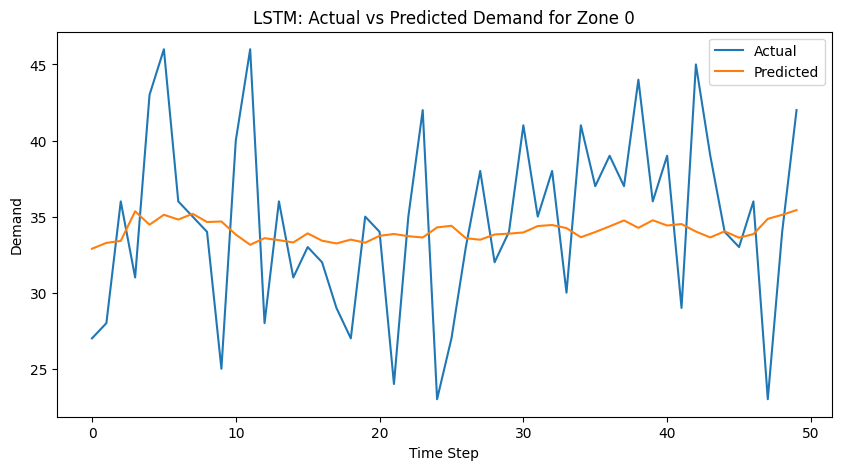

In [18]:
zone_idx = 0

plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:50, zone_idx], label='Actual')
plt.plot(y_pred[:50, zone_idx], label='Predicted')
plt.title(f'LSTM: Actual vs Predicted Demand for Zone {zone_idx}')
plt.xlabel('Time Step')
plt.ylabel('Demand')
plt.legend()
plt.show()

In [19]:

zone_results = []

for i in range(y_test_actual.shape[1]):
    zone_mae = mean_absolute_error(y_test_actual[:, i], y_pred[:, i])
    zone_rmse = np.sqrt(mean_squared_error(y_test_actual[:, i], y_pred[:, i]))
    zone_results.append([i, zone_mae, zone_rmse])

zone_results_df = pd.DataFrame(zone_results, columns=['zone', 'MAE', 'RMSE'])
zone_results_df

,zone,MAE,RMSE
0,0,5.368003,7.174439
1,1,4.731998,6.421031
2,2,3.509220,4.531466
3,3,3.122872,4.119247
4,4,5.769597,7.670361
5,5,4.799837,6.388475
6,6,3.792511,5.146756
7,7,3.338474,4.282928
8,8,3.591135,4.852223
9,9,4.095472,5.150247


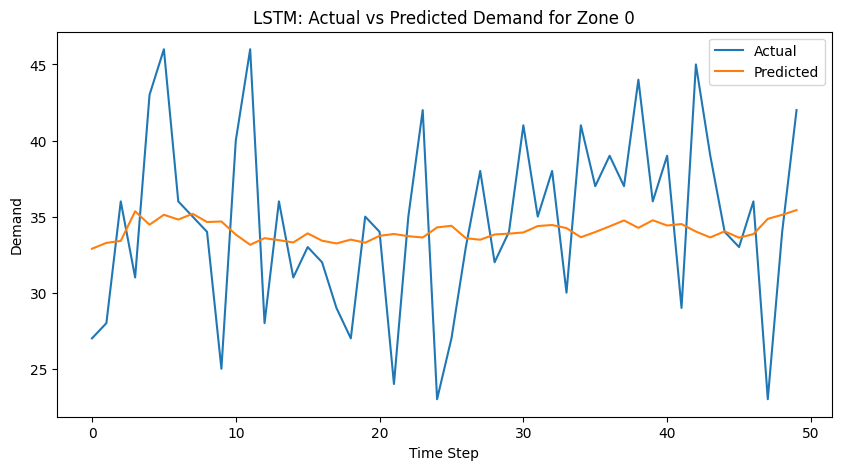

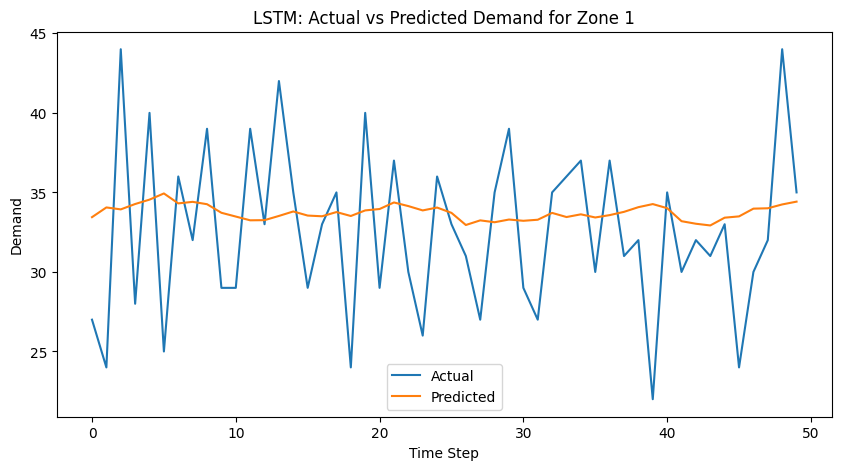

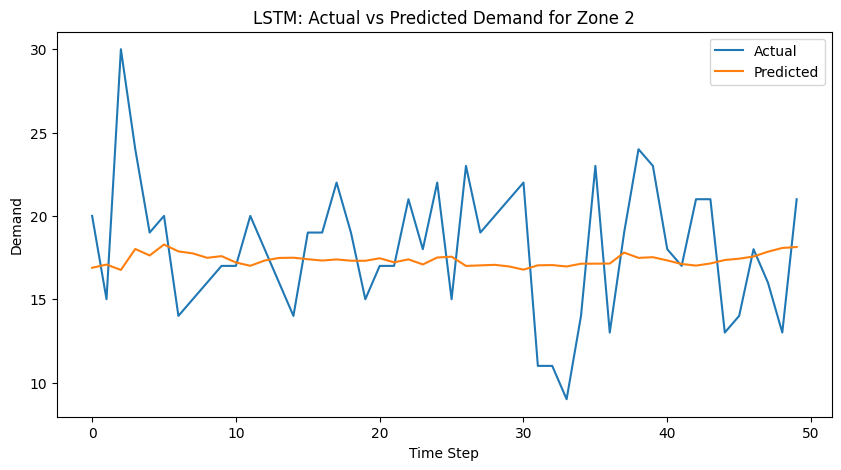

In [20]:
for zone_idx in [0, 1, 2]:
    plt.figure(figsize=(10,5))
    plt.plot(y_test_actual[:50, zone_idx], label='Actual')
    plt.plot(y_pred[:50, zone_idx], label='Predicted')
    plt.title(f'LSTM: Actual vs Predicted Demand for Zone {zone_idx}')
    plt.xlabel('Time Step')
    plt.ylabel('Demand')
    plt.legend()
    plt.show()

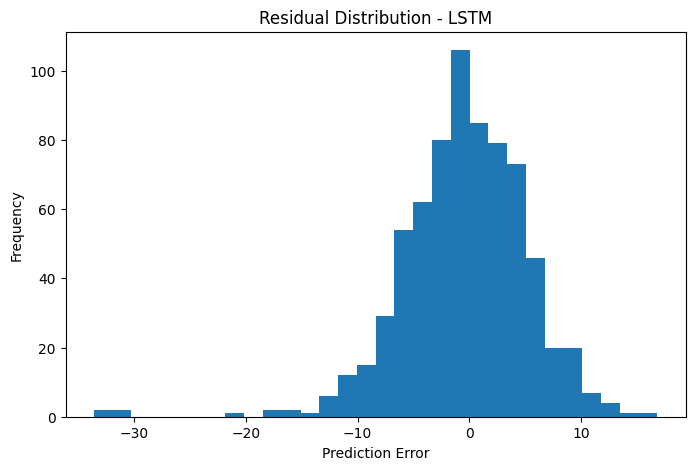

In [21]:
residuals = y_test_actual - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals.flatten(), bins=30)
plt.title("Residual Distribution - LSTM")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [22]:
zone_results_df.to_csv("lstm_zonewise_results.csv", index=False)

lstm_overall_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae, rmse]
})
lstm_overall_results.to_csv("lstm_overall_results.csv", index=False)

The LSTM baseline model demonstrated the ability to capture general temporal trends in delivery demand across zones, achieving reasonable performance in terms of MAE and RMSE. However, the model produced relatively smooth predictions and failed to accurately capture sudden spikes and drops in demand. Zone-wise analysis further revealed variability in prediction accuracy, with certain zones exhibiting higher error due to more volatile demand patterns. Additionally, residual analysis showed that while predictions are generally unbiased, significant errors occur during periods of rapid demand fluctuation. These findings highlight a key limitation of the LSTM model — its inability to capture spatial dependencies between zones, which motivates the use of graph-based models such as T-GCN.

### TGCN

Installing required Libararies

In [26]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

In [27]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
adj_tensor = torch.tensor(adj_matrix, dtype=torch.float32)

converting adjacency to edge index

In [29]:
edge_index = adj_tensor.nonzero().t().contiguous()

Defining TGCN model

In [31]:
import torch.nn as nn
from torch_geometric.nn import GCNConv

class TGCN(nn.Module):
    def __init__(self, num_nodes, hidden_dim):
        super(TGCN, self).__init__()
        
        self.gcn = GCNConv(num_nodes, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_nodes)

    def forward(self, X, edge_index):
        batch_size, seq_len, num_nodes = X.shape
        
        gcn_outputs = []
        
        for t in range(seq_len):
            x_t = X[:, t, :]  # (batch, nodes)
            
            # Apply GCN
            x_t = self.gcn(x_t, edge_index)
            gcn_outputs.append(x_t)
        
        gcn_outputs = torch.stack(gcn_outputs, dim=1)
        
        # GRU for temporal learning
        gru_out, _ = self.gru(gcn_outputs)
        
        # Take last time step
        out = self.fc(gru_out[:, -1, :])
        
        return out

initialising model

In [33]:
num_nodes = X.shape[2]
model = TGCN(num_nodes=num_nodes, hidden_dim=32)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training model

In [35]:
epochs = 50

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    output = model(X_tensor, edge_index)
    loss = criterion(output, y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 658.861572265625
Epoch 10, Loss: 623.7107543945312
Epoch 20, Loss: 602.7393188476562
Epoch 30, Loss: 588.2310791015625
Epoch 40, Loss: 573.9804077148438


evaluating model

In [37]:
model.eval()

with torch.no_grad():
    y_pred = model(X_tensor, edge_index).numpy()